=== Leaky Integrate and Fire Neuron Simulator ===
Enter functions using t (time), math.*, np.*
leave blank to use constant default values (Default at rheobase)



Enter I(t) [default: 1.5]: 1.5000009
Enter V_thr(t) [default: -55]: 
Enter R(t) [default: 10]: 


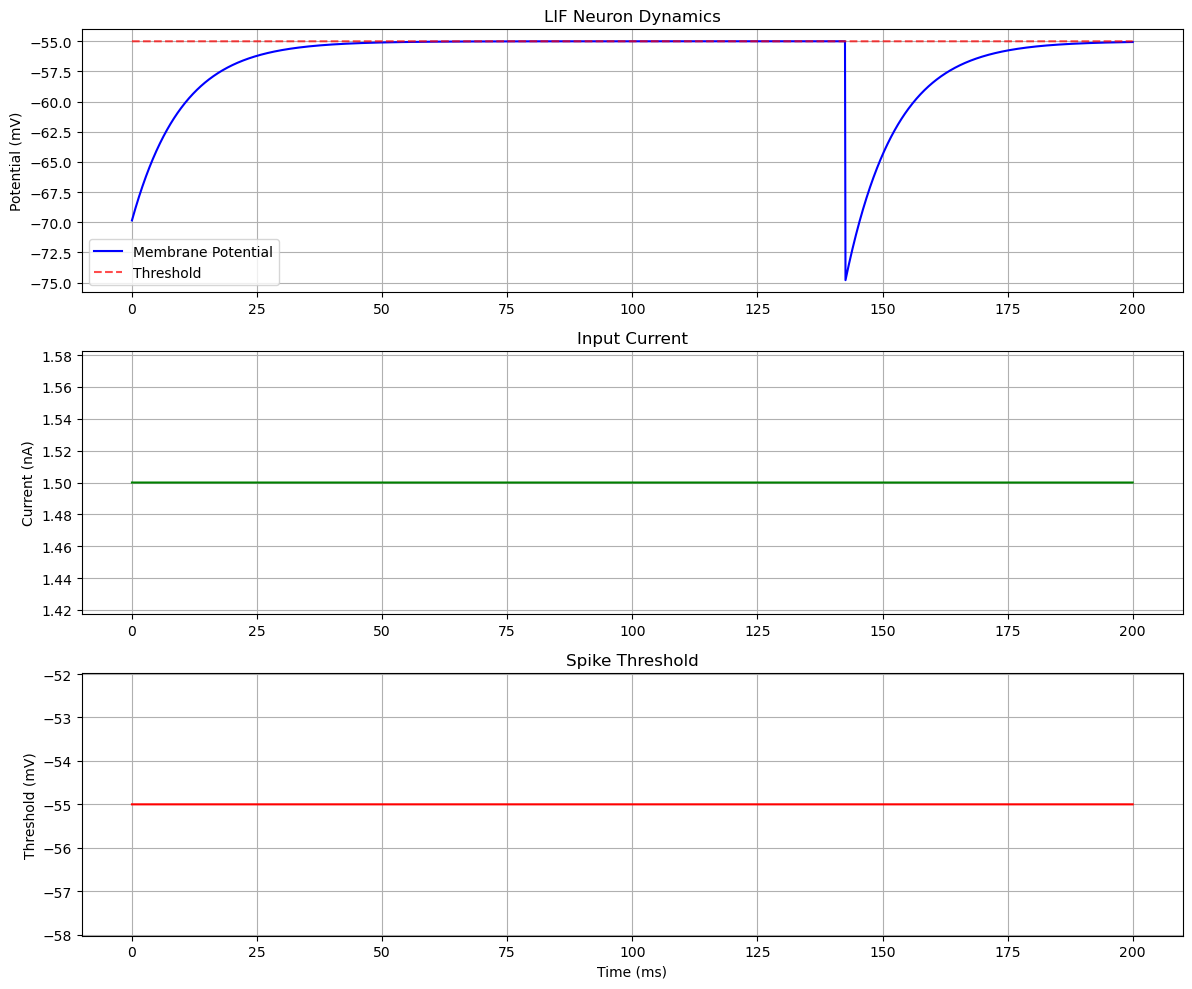

Simulation complete. Total spikes: 1
Spike times: ['142.6ms']


In [33]:
# leaky Integrate and Fire Neuron Model
# CSE 1505
# 11-17-25
# Strider Settgast

import math
import numpy as np
import matplotlib.pyplot as plt

class LIFNeuron:
    def __init__(self):
        # Default parameters
        self.V_rest = -70.0
        self.V_reset = -75.0
        self.tau_m = 10.0
        self.dt = .1

        # Function based parameters (default to constants)
        self.I_func = lambda t: 1.5
        self.V_thr_func = lambda t: -55.0
        self.R_func = lambda t: 10.0

    def set_parameter_function(self, param_name, func_str):
        #Set a parameter as a function of time
        try:
            compiled_func = compile(func_str, '<string>', 'eval')
            func = lambda t: eval(compiled_func, {'t': t, 'math': math, 'np' : np})

            if param_name == 'I':
                self.I_func = func
            elif param_name == 'V_thr':
                self.V_thr_func = func
            elif param_name == 'R':
                self.R_func = func
            else:
                print(f"Unknown parameter: {param_name}")

        except Exception as e:
            print(f"Error compiling function for {param_name}")

    def simulate(self, simulation_time=100):
        V = self.V_rest
        t = 0
        spike_times = []
        time_points = []
        voltage_trace = []
        current_trace = []
        threshold_trace = []

        while t < simulation_time:
            # Evaluate all functions at time t
            I = self.I_func(t)
            V_thr = self.V_thr_func(t)
            R = self.R_func(t)

            current_trace.append(I)
            threshold_trace.append(V_thr)
            
            # Check for spike
            if V >= V_thr:
                spike_times.append(t)
                V = self.V_reset
                
            # Integrate
            dV_dt = (-(V - self.V_rest) + I * R) / self.tau_m
            V += dV_dt * self.dt

            time_points.append(t)
            voltage_trace.append(V)
            t+= self.dt

        return time_points, voltage_trace, current_trace, threshold_trace, spike_times

def run_simulation():
    neuron = LIFNeuron()

    print("=== Leaky Integrate and Fire Neuron Simulator ===")
    print("Enter functions using t (time), math.*, np.*")
    print("leave blank to use constant default values (Default at rheobase)")
    print()

     # Get function inputs
    I_func_str = input("Enter I(t) [default: 1.5]:").strip()
    if I_func_str:
        neuron.set_parameter_function('I', I_func_str)

    V_thr_func_str = input("Enter V_thr(t) [default: -55]:").strip()
    if V_thr_func_str:
        neuron.set_parameter_function('V_thr', V_thr_func_str)

    R_func_str = input("Enter R(t) [default: 10]:").strip()
    if R_func_str:
        neuron.set_parameter_function('R', R_func_str)

    # Run simulation
    time_points, voltage_trace, current_trace, threshold_trace, spike_times = neuron.simulate(200)

    # Plot results
    plt.figure(figsize=(12,10))

    plt.subplot(3,1,1)
    plt.plot(time_points, voltage_trace, 'b-', label='Membrane Potential')
    plt.plot(time_points, threshold_trace, 'r--', label='Threshold', alpha=.7)
    plt.ylabel('Potential (mV)')
    plt.title('LIF Neuron Dynamics')
    plt.legend()
    plt.grid(True)

    plt.subplot(3,1,2)
    plt.plot(time_points, current_trace, 'g-')
    plt.ylabel('Current (nA)')
    plt.title('Input Current')
    plt.grid(True)

    plt.subplot(3,1,3)
    plt.plot(time_points, threshold_trace, 'r-')
    plt.xlabel('Time (ms)')
    plt.ylabel('Threshold (mV)')
    plt.title('Spike Threshold')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Simulation complete. Total spikes: {len(spike_times)}")
    if spike_times:
        print(f"Spike times: {[f'{t:.1f}ms' for t in spike_times[:]]}") # Show first 10 spikes
# Run simulation
run_simulation()